# RL+Transformer+NLP

## 草稿
强化学习训练agent，PPO算法
NLP（bert）捕获市场信息
Transformer作为Agent的必备的可视工具
各个交易策略作为可选工具

Agent框架：
1. 决策：包含agent行为函数/模式
2. 价值函数：判断当前状态或行为对agent收益的好坏
3. 模型：agent感知环境的工具，agent的视野强度，agent的权限

4. 决策参考Sequoia
   1. 全仓
   2. 梯度回仓
   3. 将股票属性分类，而后获取近段时间的资金流向，类似opencv中的光流检测，预测趋势
5. 价值函数分为暂时分为两部分：价格走势，预计最大收益时间（即卖出点）$V(price\_ trend, sold\_ time)$。该部分预计使用NLP、Transformer实现
6. 奖励/回报设定：
   1. 及时奖励，买入点后续不再下跌（+），反之为（-）。补救措施成功(+)
   2. 补救措施：梯度回仓；购入新的股票（限定次数，并进行持续跟踪，若收益曲线（求导）持续降低则重罚）
   3. 设置时间反比函数作为惩罚项
   4. 现实时间早上9:30前，执行Sequoia可以获得奖励，其余时间段给出等值惩罚

动态运行队列：
Agent行为帧：买入，卖出，决策帧，调整视野（回溯多少天前的数据）
决策帧：及时调整不同子决策权重,Sequoia提供的代码视作Agent的可选装备工具
环境监测帧：多久捕获一次环境数据（市场情绪，价格，交易量，以及重新计算均值线等）

- Backtrader: 在构建好自己的购买策略后可以迅速的进行股票回测，注意回测时使用后复权或者不复权的数据
- finbert: 分析师语言情感分析（https://huggingface.co/yiyanghkust/finbert-tone-chinese）
- 爬虫（待定）: 市场评论捕获
- DDPG: 强化学习算法
- akshare: 免费股票数据获取
- TA-lib: 股票指标计算
- Sequoia: 预设交易策略

In [3]:
import akshare as ak
import backtrader as bt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch as t
import torch.nn as nn
import time

In [9]:
stock_code = "SH002409"

可选行为：<br>
买入、卖出、选择预设策略、选择调用NLP分析、选择Transformer获取历史数据并预测趋势、是否获取当前价格（环境：限制最小时间间隔20min，过小给出惩罚）

预设训练策略：<br>
设置虚拟时间表；<br>
环境设置，每5min中更新一次数据，累积奖励到一定阈值后将时间间隔增长，依次设置为[5min, 10min, 15min, 20min]

选股流程：<br>
执行Sequoia中的prepare，根据近三个月的股票数据进行筛选

训练结算需要设定条件或日期：
1. 亏损至百分之多少；
2. 最长时间周期20或30天

训练大致流程：
1. 先使用不带新闻信息的数据进行训练(LSTM) -- 预训练
2. 添加新闻标签，新闻标签采用个股新闻信息为主，公告信息为辅，考虑使用qwen3-8b-finance模型(huggingface下载)
3. 加入Transformer框架混合训练Agent

当前进度：

选股模块：

1. 量化数据采集 -- 已完成
2. 量化指标生成 -- 已完成
3. 量化数据增量更新或实时获取 -- 待完成
4. 量化数据DataLoader -- 已完成
5. LSTM预训练（不含新闻信息）-- 已完成
6. LSTM预训练调优 -- 待完成
7. 新闻信息采集 -- 待完成
8. NLP模型部署：qwen3-8B-financial Q6_k[模型](https://huggingface.co/mradermacher/Qwen3-8B-Financial-Numerical-Reasoning-GGUF)本地部署 --- 待完成
9. NLP模型部署：测试 -- 待完成
10. 新闻文本量化 -- 待完成
11. 新闻文本增量更新 -- 待完成
12. Transformer框架部分搭建 -- 待完成
13. 量化数据和新闻量化数据合并 -- 待完成

DRL交易模块：

1.  agent environment构建 -- 待完成
2.  action及critical模型（离线）-- 待完成
3.  DRL测试 -- 待完成
4.  回测算法 -- 待完成
5.  DRL实时运行 -- 待完成

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from stockagent.utils.data import StockDataset
from torch.utils.data import DataLoader
from scipy.stats import pearsonr

### LSTM-预训练

In [ ]:
train_data = StockDataset("./train_data.lmdb", transform=torch.Tensor)
train_loader = DataLoader(train_data, batch_size=128, pin_memory=True, shuffle=False)
valid_data = StockDataset("./valid_data.lmdb", transform=torch.Tensor)
valid_loader = DataLoader(valid_data, batch_size=32, pin_memory=True, shuffle=False) ##禁止shuffle, 防止泄露未来信息

In [ ]:
class LSTM(nn.Module):
    def __init__(self, input_dim: int = 27, hidden_dim: int = 96, num_layers: int =2,
                 dropout: float = 0.25, use_layer_norm: bool = False):
        super().__init__()

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, 
                            dropout = dropout if num_layers > 1 else 0.0)
        self.use_layer_norm = use_layer_norm
        if use_layer_norm:
            self.layer_norm = nn.LayerNorm(hidden_dim)
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
        self.tanh = nn.Tanh()
    
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        out = out[:, -1, :]
        if self.use_layer_norm:
            out = self.layer_norm(out)
        
        out = self.fc(out).squeeze(-1)
        return self.tanh(out)

In [ ]:
class Trainer():
    def __init__(self, model: nn.Module, train_loader: DataLoader, valid_loader: DataLoader,
                 optimizer: torch.optim.Optimizer, criterion: nn.Module, 
                 scheduler: torch.optim.lr_scheduler._LRScheduler, device: torch.device,
                 early_stop_step: int = 8, num_epoches: int= 500,
                 save_dir: str = "stockagent/lstmcheckpoint/"):
        
        self.model = model.to(device)
        self.train_loader = train_loader
        self.valid_loader = valid_loader
        self.num_epoches = num_epoches
        self.optimizer = optimizer
        self.critertion = criterion
        self.device = device
        self.lr_scheduler = scheduler
        
        self.early_stop_step = early_stop_step
        self.save_dir = save_dir

        self.best_val_ic = 0
        self.pre_val_ic = -1
        self.epochs_no_improve = 0

        self.history = {
            "train_loss": [],
            "train_acc": [],  #accuracy
            "val_loss": [],
            "val_acc": [],
            "ic_value": [],
        }
    
    def run(self):
        for epoch in range(self.num_epoches):
            self.train(epoch)
            ic = self.valid(epoch)
            print(f"IC value: {ic}")
            self.history["ic_value"].append(ic)
            if self._early_stopping(ic):
                print("Best IC value model saved")
                break
        self.plot()

    def train(self, epoch):
        self.model.train()
        epoch_loss, epoch_acc, _, _ = self._epoch(self.train_loader, f"Training [{epoch+1}/{self.num_epoches}]")
        self.history["train_loss"].append(epoch_loss)
        self.history["train_acc"].append(epoch_acc)
        return None

    def valid(self, epoch):
        self.model.eval()
        with torch.no_grad():
            epoch_loss, epoch_acc, all_pred, all_labels = self._epoch(self.valid_loader, f"Validing [{epoch+1}/{self.num_epoches}]")
        self.history["val_loss"].append(epoch_loss)
        self.history["val_acc"].append(epoch_acc)
        self._update_learning_rate(epoch_loss)
        ic = self.compute_ic(torch.cat(all_pred), torch.cat(all_labels))
        return ic

    def plot(self):
        fig, ax = plt.subplots(1, 2, clear = True, figsize = (12, 5))
        xtick = list(range(1, self.num_epoches+1,1))
        ax[0].plot(self.history["train_loss"], linestyle = "-.", color = "red", label = "train")
        ax[0].plot(self.history["val_loss"], linestyle = "--", color = "green", label = "valid")
        ax[0].spines[["top", "right"]].set_color(None)
        ax[0].set_title("Loss Curve")
        ax[0].set_xlabel("Epoches")
        ax[0].set_ylabel("Loss")
        ax[0].legend(title = None)
        ax[1].plot(self.history["train_acc"], linestyle = "-.", color = "red", label = "train")
        ax[1].plot(self.history["val_acc"], linestyle = "--", color = "green", label = "valid")
        ax[1].spines[["top", "right"]].set_color(None)
        ax[1].set_title("Accuracy Curve")
        ax[0].set_xlabel("Epoches")
        ax[0].set_ylabel("Accuracy")
        ax[1].legend(title = None)
        plt.show()
        plt.close()

    def _epoch(self, dataloader, desc, use_col = -3):
        losses = 0.0
        correct, total = 0, 0
        all_pred, all_label = [], []
        with tqdm(dataloader, desc= desc) as pbar:
            for inputs, labels in pbar:
                inputs = inputs.to(self.device)
                labels = labels[:, -1, use_col]
                # winsorize 缩尾处理
                min= torch.quantile(labels, 0.01, interpolation='linear')
                max = torch.quantile(labels, 0.99, interpolation='linear')
                
                labels = torch.clamp(labels, min, max).to(self.device)
                labels_trend = labels.gt(0)
                if desc == "Training":
                    self.optimizer.zero_grad()
                out = self.model(inputs)
                loss = self.critertion(out, labels)
                if "Training" in desc:
                    loss.backward()
                    self.optimizer.step()
                else:
                    all_pred.append(out)
                    all_label.append(labels)
                losses += loss.item()
                total += labels.shape[0]
                out_trend = out.gt(0)
                correct += out_trend.eq(labels_trend).sum().item()
                pbar.set_postfix({
                    "loss": losses / (pbar.n + 1),
                    "trend_acc": 100. * correct/total
                })
        epoch_loss = losses / len(self.train_loader)
        epoch_acc = 100. * correct / total
        return epoch_loss, epoch_acc, all_pred, all_label
    
    def _update_learning_rate(self, val_loss: float):
        if self.lr_scheduler is not None:
            if isinstance(self.lr_scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                self.lr_scheduler.step(val_loss)
            else:
                self.lr_scheduler.step()

    def _early_stopping(self, ic: float):
        if len(self.history["train_loss"]) > 100:
            if (ic - self.pre_val_ic) > 0.0005 :
                self.best_val_ic = ic
                self.epochs_no_improve = 0
                torch.save(self.model.state_dict(), f"{self.save_dir}/best_model.pth")
                self.pre_val_ic = ic
                return False
            else:
                self.epochs_no_improve += 1
                self.pre_val_ic = ic
                return self.epochs_no_improve >= self.early_stop_step
        else:
            return False
    
    def compute_ic(self, preds, labels):
        """
        计算信息系数（Information Coefficient）
        
        Parameters:
            preds (Tensor or array): 模型预测值，shape [N]
            labels (Tensor or array): 真实标签（如 future_avg_return），shape [N]
        
        Returns:
            float: IC 值（-1 ~ 1），越高越好
        """
        # 转为 numpy（兼容 torch / numpy）
        if isinstance(preds, torch.Tensor):
            preds = preds.detach().cpu().numpy()
        if isinstance(labels, torch.Tensor):
            labels = labels.detach().cpu().numpy()
        
        # 移除 NaN 或 Inf（防止数值错误）
        valid_mask = np.isfinite(preds) & np.isfinite(labels)
        preds_clean = preds[valid_mask]
        labels_clean = labels[valid_mask]

        if len(preds_clean) < 2:
            return 0.0
        
        # 计算 Pearson 相关系数
        ic, _ = pearsonr(preds_clean, labels_clean)
        return float(ic)

In [ ]:
model = LSTM()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-5, weight_decay= 1e-5)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
trainer = Trainer(model, train_loader, valid_loader, optimizer, criterion, scheduler, device)

In [ ]:
trainer.run()

In [ ]:
trainer.best_val_ic

### 交易策略

In [ ]:
import sys
sys.path.append("./Sequoia")
from Sequoia.main import main

In [ ]:
main(source = "tx")

### TFT选股
Temporal Fusion Transformer，TFT

In [ ]:
import gc
import pandas as pd
import lightning.pytorch as pl
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, QuantileLoss, RMSE, MAE
from pytorch_forecasting.data import GroupNormalizer
from pytorch_lightning.loggers import CSVLogger
from lightning.pytorch.tuner import Tuner
from stockagent.utils.sql import SQLData

In [87]:
training_cutoff = "20150101"
val_cutoff = "20240101"
target = "future_avg_return"
sqldata = SQLData()
sqldata.connect()
code2id_sql = "SELECT stock_id, stock_code FROM stock_codes;"
query_sql = "SELECT * FROM stock_price_data_rm WHERE date < ?"
val_sql = "SELECT * FROM stock_price_data_rm WHERE date >= ?"
train_data = pd.read_sql(query_sql, sqldata.conn, params=(training_cutoff, ))
val_data = pd.read_sql(val_sql, sqldata.conn, params=(val_cutoff, ))
code2id = pd.read_sql(code2id_sql, sqldata.conn)
sqldata.close()

train_data = pd.merge(train_data, code2id, how = "left", on = "stock_id").dropna(axis = 0)
##update code2id
code2id = train_data.loc[:, ["stock_id", "stock_code"]].drop_duplicates()
val_data = pd.merge(val_data, code2id, how="left", on = "stock_id").dropna(axis = 0)

max_encoder_length = 21
max_prediction_length = 6
train_data = train_data.sort_values(["stock_code", "date"])
train_data = train_data.drop(["data_id", "stock_id", "date"], axis = 1)
train_data = train_data.astype({"up_limit": int, "down_limit": int}).astype({"up_limit": str, "down_limit": str})

train_data["time_idx"] = train_data.groupby("stock_code").cumcount()
val_data = val_data.sort_values(["stock_code", "date"])
val_data = val_data.drop(["data_id", "stock_id", "date"], axis = 1)
val_data["time_idx"] = val_data.groupby("stock_code").cumcount()
val_data = val_data.astype({"up_limit": int, "down_limit": int}).astype({"up_limit": str, "down_limit": str})

pred_reals = ["Log_profit", "future_avg_return", "vol_ma5", "vol_ratio"]
features = train_data.columns.to_list()
features.remove("stock_code")
features.remove("up_limit")
features.remove("down_limit")
for i in pred_reals:
    features.remove(i)

unknown_reals和 static_categoricals, group_ids中的内容不能重复，time_idx也不能包含在unknown_reals内

In [89]:
train_dataset = TimeSeriesDataSet(train_data,
                                  time_idx="time_idx",
                                  target = "future_avg_return",
                                  static_categoricals= ["stock_code"],
                                  group_ids=["stock_code"],
                                  min_encoder_length = max_encoder_length // 2,
                                  max_encoder_length = max_encoder_length,
                                  min_prediction_length=1,
                                  max_prediction_length=1,
                                  time_varying_known_categoricals=["up_limit", "down_limit"],
                                  time_varying_unknown_reals = features,
                                  target_normalizer=GroupNormalizer(groups=["stock_code"]),
                                  add_relative_time_idx=True,
                                  add_target_scales=True,
                                  add_encoder_length=True,
                                  allow_missing_timesteps=True,
                                  )
valid_dataset = TimeSeriesDataSet.from_dataset(train_dataset, val_data, stop_randomization=True, predict=True)
# del train_data, val_data
# gc.collect()

e:\code\venv\Lib\site-packages\pytorch_forecasting\data\timeseries\_timeseries.py:1850: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 1 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__stock_code': 'sh601225'}]
  warnings.warn(


In [90]:
batch_size = 128
train_dataloader = train_dataset.to_dataloader(train=True, batch_size=batch_size, num_workers=0, shuffle = False)
val_dataloader = valid_dataset.to_dataloader(train=False, batch_size=batch_size, num_workers=0, shuffle = False)

In [91]:
early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=3, verbose=False, mode="min")
lr_logger = LearningRateMonitor()
loss_logger = CSVLogger("lightning_logs", name="tft_close_prediction")
board_logger = TensorBoardLogger("lightning_logs", name = "Board")
trainer = pl.Trainer(
    max_epochs=100, 
    devices = "auto",
    enable_model_summary = True,
    accelerator="auto",  # run on CPU, if on multiple GPUs, use strategy="ddp"
    gradient_clip_val=0.1,
    limit_train_batches=256,
    limit_val_batches=256,
    callbacks=[lr_logger, early_stop_callback],
    check_val_every_n_epoch=5,
    logger=board_logger
)
tft = TemporalFusionTransformer.from_dataset(
    # dataset
    train_dataset,
    # architecture hyperparameters
    hidden_size=128,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=32,
    # loss metric to optimize
    loss=MAE(),
    # logging frequency
    log_interval=2,
    # optimizer parameters
    learning_rate=1e-4,
    output_size = 1,
    weight_decay = 1e-3,
    reduce_on_plateau_patience=4
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
e:\code\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
e:\code\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:210: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [92]:
## training
trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | MAE                             | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 211 K  | train | 0    
3  | prescalers                         | ModuleDict                      | 1.9 K  | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 35.0 K | train | 0    
5  | encoder_variable_selection         | VariableSelectionNetwork        | 336 K  | train | 0    
6  | decoder_variable_selection         | VariableSelectionNetwork        | 12.6 K | train | 0    
7  | static_context_variable_selection  | GatedResidualNetwo

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

e:\code\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
e:\code\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

e:\code\venv\Lib\site-packages\lightning\pytorch\loops\training_epoch_loop.py:500: ReduceLROnPlateau conditioned on metric val_loss which is not available but strict is set to `False`. Skipping learning rate update.


Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [93]:
best_model_path = trainer.checkpoint_callback.best_model_path

In [101]:
train_dataset.time_varying_unknown_reals

['open',
 'close',
 'low',
 'high',
 'amount',
 'SMA_10',
 'SMA_20',
 'SMA_50',
 'EMA_12',
 'EMA_26',
 'MACD',
 'MACD_Signal',
 'MACD_Hist',
 'RSI_14',
 'ROC_10',
 'MOM_10',
 'ATR_14',
 'STD_20',
 'BB_b',
 'OBV',
 'AD',
 'ADOSC',
 'hl2',
 'hlc3',
 'ohlc4',
 'time_idx']

In [94]:
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path, weights_only = False)

e:\code\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
e:\code\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:210: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [95]:
predictions = best_tft.predict(
    val_dataloader, return_x=True, trainer_kwargs=dict(accelerator="auto")
)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
e:\code\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


In [ ]:
import matplotlib.pyplot as plt

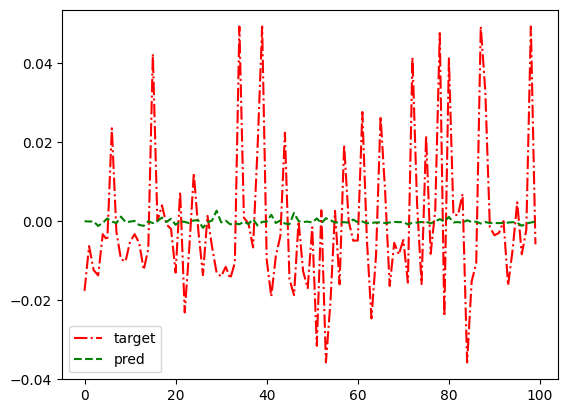

In [96]:
plt.plot(predictions.x["decoder_target"][:100], c = "red", linestyle = "-.", label = "target")
plt.plot(predictions.output[:100], c = "green", linestyle = "--", label = "pred")
plt.legend()
plt.show()

In [82]:
predictions.x["decoder_target"]

tensor([[-0.0177],
        [-0.0063],
        [-0.0124],
        ...,
        [ 0.0236],
        [-0.0113],
        [ 0.0023]])

- 进行缩尾处理后，模型Loss开始收敛，现在训练完毕后，如何利用模型对下一天做多或做空的股票进行排序？

需要进一步实现交易策略，考虑强化学习

- 预测未来5日收益值总是收敛到0？

股票价格变化近似于马尔可夫模型，具有不可预测的性质，后续需要调整标签值，为波动率或者当日内所有股票的排序